In [4]:
import pandas as pd

df = pd.read_csv("ev_sales_by_makers_and_cat_15-24.csv")

print("Dataset Loaded Successfully")

display(df.head())

Dataset Loaded Successfully


,Cat,Maker,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,3W,"""VOLVO GROUP INDIA PVT LTD""",0,0,31,12,0,0,0,0,0,0
1,3W,3EV INDUSTRIES PVT LTD,0,0,0,0,0,0,112,390,545,51
2,2W,3GB TECHNOLOGY PVT LTD,0,0,0,1,0,0,0,0,0,0
3,3W,3GB TECHNOLOGY PVT LTD,0,1,1,0,0,0,0,0,0,0
4,3W,3S INDUSTRIES PRIVATE LIMITED,0,0,0,0,48,66,43,68,266,578


In [ ]:
print(df.info())

display(df.describe())

print("\nMissing Values")

display(df.isnull().sum())

In [ ]:
# Remove duplicate rows

df = df.drop_duplicates()

# Fill missing values with 0

df = df.fillna(0)

print("Duplicates Removed")

print("Missing Values Filled")

print(df.shape)

display(df.head())

In [5]:
# Convert category columns

df["Cat"] = df["Cat"].astype("category")
df["Maker"] = df["Maker"].astype("category")

print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 1386 entries, 0 to 1385
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype   
---  ------  --------------  -----   
 0   Cat     1386 non-null   category
 1   Maker   1386 non-null   category
 2   2015    1386 non-null   int64   
 3   2016    1386 non-null   int64   
 4   2017    1386 non-null   int64   
 5   2018    1386 non-null   int64   
 6   2019    1386 non-null   int64   
 7   2020    1386 non-null   int64   
 8   2021    1386 non-null   int64   
 9   2022    1386 non-null   int64   
 10  2023    1386 non-null   int64   
 11  2024    1386 non-null   int64   
dtypes: category(2), int64(10)
memory usage: 121.8 KB
None


In [6]:
import sqlite3

conn = sqlite3.connect(':memory:')

df.to_sql('ev_data', conn, index=False, if_exists='replace')

query = """

SELECT

Cat,

SUM("2015"+ "2016"+ "2017"+ "2018"+ "2019"+ "2020"+ "2021"+ "2022"+ "2023"+ "2024") AS Total_Sales

FROM ev_data

GROUP BY Cat

ORDER BY Total_Sales DESC;

"""

result1 = pd.read_sql_query(query, conn)

display(result1)

conn.close()

,Cat,Total_Sales
0,2W,2279448
1,3W,1934263
2,LMV,206388
3,MMV,804


In [7]:
import sqlite3

conn = sqlite3.connect(':memory:')

df.to_sql('ev_data', conn, index=False, if_exists='replace')

query = """

SELECT

Maker,

SUM("2015"+ "2016"+ "2017"+ "2018"+ "2019"+ "2020"+ "2021"+ "2022"+ "2023"+ "2024") AS Total_Sales

FROM ev_data

GROUP BY Maker

ORDER BY Total_Sales DESC

LIMIT 10;

"""

result2 = pd.read_sql_query(query, conn)

display(result2)

conn.close()

,Maker,Total_Sales
0,OLA ELECTRIC TECHNOLOGIES PVT LTD,588266
1,TVS MOTOR COMPANY LTD,318445
2,ATHER ENERGY PVT LTD,236387
3,HERO ELECTRIC VEHICLES PVT. LTD,201785
4,BAJAJ AUTO LTD,198498
5,OKINAWA AUTOTECH PVT LTD,196182
6,YC ELECTRIC VEHICLE,152951
7,AMPERE VEHICLES PRIVATE LIMITED,141805
8,SAERA ELECTRIC AUTO PVT LTD,87481
9,MAHINDRA & MAHINDRA LIMITED,84794


In [8]:
import sqlite3

conn = sqlite3.connect(':memory:')

df.to_sql('ev_data', conn, index=False, if_exists='replace')

query = """

SELECT

Cat,

AVG("2024") AS Average_2024_Sales,

MAX("2024") AS Maximum_2024_Sales,

COUNT(*) AS Number_of_Makers

FROM ev_data

GROUP BY Cat

ORDER BY Average_2024_Sales DESC;

"""

result3 = pd.read_sql_query(query, conn)

display(result3)

conn.close()

,Cat,Average_2024_Sales,Maximum_2024_Sales,Number_of_Makers
0,2W,2108.624521,211273,261
1,3W,429.579677,34331,866
2,LMV,233.623967,35830,242
3,MMV,2.294118,20,17


In [9]:
print(result2.describe())

         Total_Sales
count      10.000000
mean   220659.400000
std    146586.661528
min     84794.000000
25%    144591.500000
50%    197340.000000
75%    227736.500000
max    588266.000000


In [11]:
result2.to_csv("top10_ev_makers.csv", index=False)

print("CSV Exported Successfully")

CSV Exported Successfully


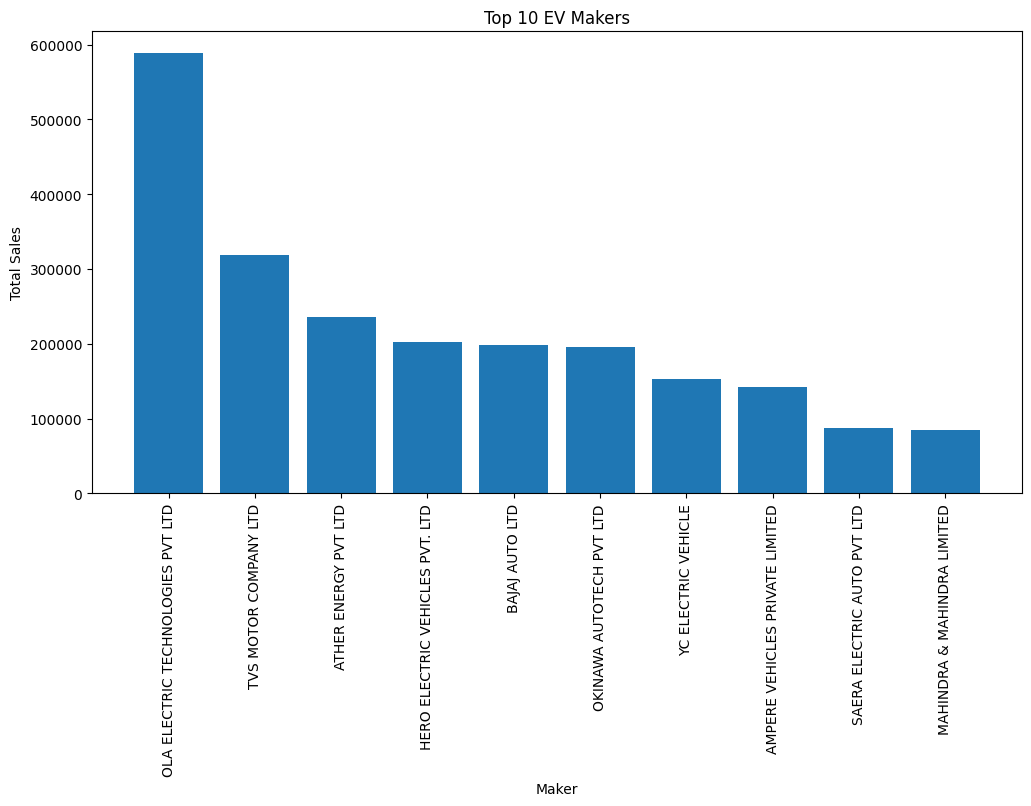

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.bar(result2["Maker"], result2["Total_Sales"])

plt.xticks(rotation=90)

plt.title("Top 10 EV Makers")

plt.xlabel("Maker")

plt.ylabel("Total Sales")

plt.show()

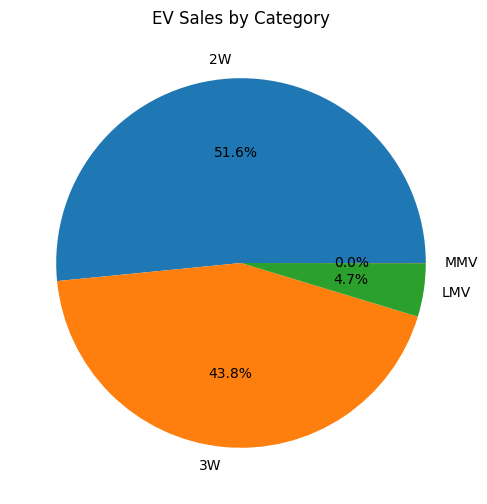

In [13]:
plt.figure(figsize=(6,6))

plt.pie(result1["Total_Sales"],
        labels=result1["Cat"],
        autopct='%1.1f%%')

plt.title("EV Sales by Category")

plt.show()

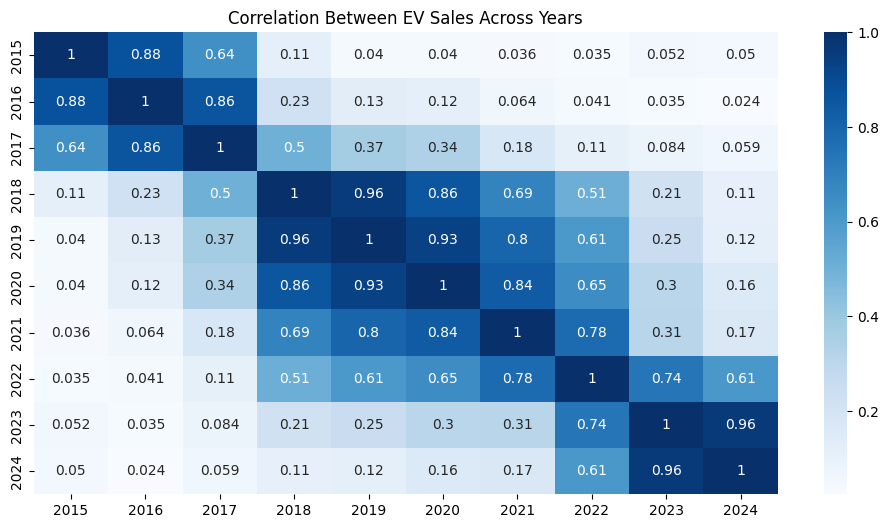

In [14]:
import seaborn as sns

years = df.iloc[:,2:]

plt.figure(figsize=(12,6))

sns.heatmap(years.corr(), annot=True, cmap="Blues")

plt.title("Correlation Between EV Sales Across Years")

plt.show()

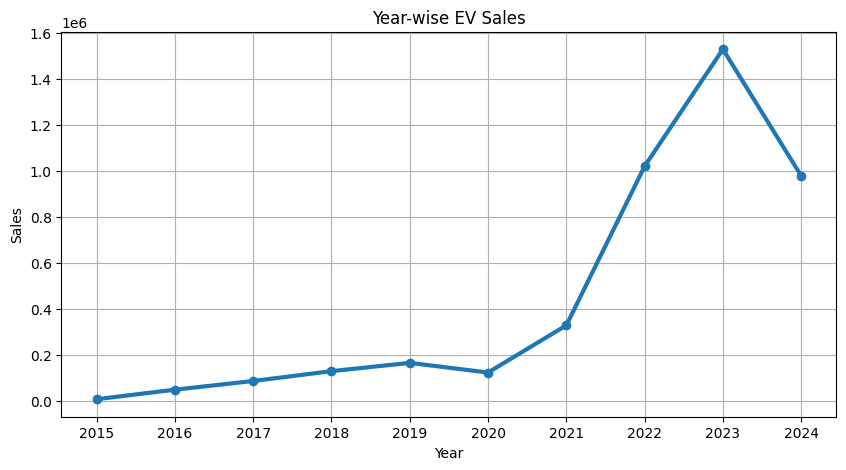

In [15]:
year_sales = df.iloc[:,2:].sum()

plt.figure(figsize=(10,5))

plt.plot(year_sales.index,
         year_sales.values,
         marker='o',
         linewidth=3)

plt.title("Year-wise EV Sales")

plt.xlabel("Year")

plt.ylabel("Sales")

plt.grid()

plt.show()